# Manifold Consistency Module — Interactive Test

Test notebook for `src/models/manifold.py` (Week 3, Task 1)

**Checklist:**
1. Import & build k-NN graph
2. Compute manifold consistency loss
3. Optimize weights → verify loss decreases
4. Visualize loss curve
5. k-NN preservation diagnostic
6. Band weight analysis

In [1]:
import sys, os
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

from src.models.manifold import (
    build_knn_graph,
    build_knn_graph_with_distances,
    manifold_consistency_loss,
    compute_fused_embedding,
    check_knn_preservation,
)

print("Imports OK")

Imports OK


## 1. Setup — Simulated Band Embeddings

Simulate 13 Sentinel-2 band embeddings (512-dim, L2-normalized like CLIP output).

In [2]:
torch.manual_seed(42)

B, D = 13, 512  # 13 bands, 512-dim CLIP embeddings
band_embeddings = F.normalize(torch.randn(B, D), dim=1)

# Simulate a text query embedding
query_embedding = F.normalize(torch.randn(D), dim=0)

print(f"Band embeddings : {tuple(band_embeddings.shape)}")
print(f"Query embedding : {tuple(query_embedding.shape)}")
print(f"L2 norms (bands): {torch.norm(band_embeddings, dim=1).tolist()[:3]}... (should be ~1.0)")

Band embeddings : (13, 512)
Query embedding : (512,)
L2 norms (bands): [1.0, 1.0, 1.0]... (should be ~1.0)


## 2. Build k-NN Graph

In [3]:
k = 5
knn_indices = build_knn_graph(band_embeddings, k=k)
knn_indices_d, knn_distances = build_knn_graph_with_distances(band_embeddings, k=k)

print(f"knn_indices shape : {tuple(knn_indices.shape)} (expect ({B}, {k}))")
print(f"knn_distances shape: {tuple(knn_distances.shape)}")

BAND_NAMES = ["B01","B02","B03","B04","B05","B06","B07","B08","B8A","B09","B11","B12", "B13"]

print("\nNeighbor table (band → 5 nearest neighbors):")
for i in range(B):
    neighbors = [f"{BAND_NAMES[j]}" for j in knn_indices[i].tolist()]
    dists = [f"{d:.3f}" for d in knn_distances[i].tolist()]
    print(f"  {BAND_NAMES[i]:>3s} → {neighbors}  dists={dists}")

knn_indices shape : (13, 5) (expect (13, 5))
knn_distances shape: (13, 5)

Neighbor table (band → 5 nearest neighbors):
  B01 → ['B11', 'B05', 'B06', 'B13', 'B03']  dists=['1.392', '1.400', '1.403', '1.411', '1.414']
  B02 → ['B13', 'B03', 'B06', 'B12', 'B07']  dists=['1.368', '1.372', '1.373', '1.387', '1.390']
  B03 → ['B02', 'B13', 'B8A', 'B12', 'B11']  dists=['1.372', '1.383', '1.384', '1.388', '1.391']
  B04 → ['B11', 'B09', 'B13', 'B03', 'B8A']  dists=['1.390', '1.394', '1.399', '1.409', '1.417']
  B05 → ['B07', 'B13', 'B06', 'B01', 'B08']  dists=['1.374', '1.374', '1.381', '1.400', '1.405']
  B06 → ['B02', 'B05', 'B08', 'B11', 'B13']  dists=['1.373', '1.381', '1.393', '1.393', '1.396']
  B07 → ['B13', 'B05', 'B02', 'B08', 'B11']  dists=['1.371', '1.374', '1.390', '1.413', '1.417']
  B08 → ['B06', 'B05', 'B11', 'B09', 'B07']  dists=['1.393', '1.405', '1.405', '1.410', '1.413']
  B8A → ['B11', 'B03', 'B12', 'B09', 'B04']  dists=['1.383', '1.384', '1.402', '1.410', '1.417']
  B09 →

## 3. Manifold Consistency Loss — Basic Check

In [4]:
# Create initial fused embedding with uniform weights
uniform_weights = torch.ones(B) / B
fused = compute_fused_embedding(band_embeddings, uniform_weights, normalize_output=False)

loss = manifold_consistency_loss(fused, band_embeddings, knn_indices, lambda_m=0.1)

print(f"Fused embedding shape: {tuple(fused.shape)}")
print(f"Loss (uniform weights): {loss.item():.6f}")
print(f"Loss is scalar: {loss.ndim == 0}")
print(f"Loss is positive: {loss.item() > 0}")
print(f"Loss requires grad: {loss.requires_grad}")

Fused embedding shape: (512,)
Loss (uniform weights): 0.095801
Loss is scalar: True
Loss is positive: True
Loss requires grad: False


## 4. Optimization — Loss Curve

Optimize fusion weights via Adam to minimize manifold consistency loss.
**Critical check:** loss must decrease over steps.

In [6]:
band_emb_fixed = band_embeddings.detach()
knn_idx_fixed = build_knn_graph(band_emb_fixed, k=5)

# Learnable weights
w = torch.randn(B, requires_grad=True)
optimizer = torch.optim.Adam([w], lr=0.1)

num_steps = 50
losses = []
weight_history = []

for step in range(num_steps):
    optimizer.zero_grad()
    
    w_norm = torch.softmax(w, dim=0)
    fused_emb = compute_fused_embedding(band_emb_fixed, w_norm, normalize_output=False)
    loss = manifold_consistency_loss(fused_emb, band_emb_fixed, knn_idx_fixed, lambda_m=0.1)
    
    loss.backward()
    optimizer.step()
    
    losses.append(loss.item())
    weight_history.append(w_norm.detach().clone())

print(f"Step  0: loss = {losses[0]:.6f}")
print(f"Step 24: loss = {losses[24]:.6f}")
print(f"Step 49: loss = {losses[49]:.6f}")
print(f"\nDecrease: {(1 - losses[-1]/losses[0])*100:.2f}%")
print(f"Final loss < 1.0: {losses[-1] < 1.0} " if losses[-1] < 1.0 else f"Final loss >= 1.0 ")

Step  0: loss = 0.097230
Step 24: loss = 0.095191
Step 49: loss = 0.095074

Decrease: 2.22%
Final loss < 1.0: True 


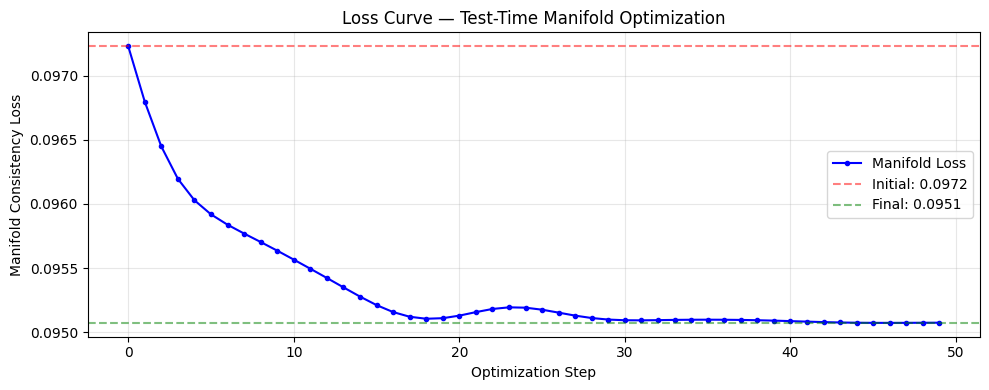

In [7]:
# --- Plot loss curve ---
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(num_steps), losses, 'b-o', markersize=3, linewidth=1.5, label='Manifold Loss')
ax.axhline(y=losses[0], color='r', linestyle='--', alpha=0.5, label=f'Initial: {losses[0]:.4f}')
ax.axhline(y=losses[-1], color='g', linestyle='--', alpha=0.5, label=f'Final: {losses[-1]:.4f}')
ax.set_xlabel('Optimization Step')
ax.set_ylabel('Manifold Consistency Loss')
ax.set_title('Loss Curve — Test-Time Manifold Optimization')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. k-NN Preservation Diagnostic

In [8]:
final_w = torch.softmax(w, dim=0).detach()
final_fused = compute_fused_embedding(band_emb_fixed, final_w, normalize_output=False)

diagnostics = check_knn_preservation(band_emb_fixed, final_fused, knn_idx_fixed)

print("k-NN Preservation Diagnostics:")
print(f"  Preservation rate  : {diagnostics['preservation_rate']:.3f} ({diagnostics['preservation_rate']*100:.1f}%)")
print(f"  Mean neighbor dist : {diagnostics['mean_neighbor_dist']:.4f}")
print()
print("Interpretation:")
print(f"  {diagnostics['preservation_rate']*100:.0f}% of original k-NN neighbors are still")
print(f"  among the closest bands to the fused embedding.")

k-NN Preservation Diagnostics:
  Preservation rate  : 0.538 (53.8%)
  Mean neighbor dist : 0.9507

Interpretation:
  54% of original k-NN neighbors are still
  among the closest bands to the fused embedding.


## 6. Weight Analysis — Which Bands Matter?

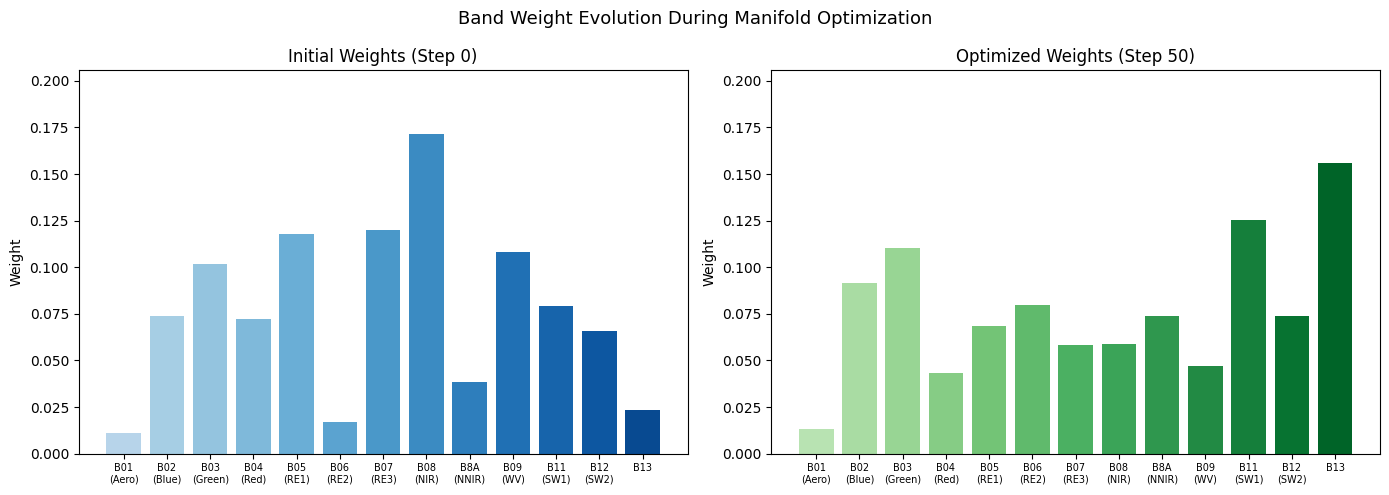


Weight changes (final - initial):
    B01 (Aero): 0.0110 → 0.0134  (↑ +0.0024)
    B02 (Blue): 0.0736 → 0.0914  (↑ +0.0177)
   B03 (Green): 0.1018 → 0.1101  (↑ +0.0083)
     B04 (Red): 0.0722 → 0.0432  (↓ -0.0289)
     B05 (RE1): 0.1177 → 0.0687  (↓ -0.0490)
     B06 (RE2): 0.0172 → 0.0798  (↑ +0.0626)
     B07 (RE3): 0.1198 → 0.0581  (↓ -0.0617)
     B08 (NIR): 0.1713 → 0.0588  (↓ -0.1126)
    B8A (NNIR): 0.0384 → 0.0739  (↑ +0.0355)
      B09 (WV): 0.1082 → 0.0472  (↓ -0.0610)
     B11 (SW1): 0.0792 → 0.1254  (↑ +0.0462)
     B12 (SW2): 0.0659 → 0.0739  (↑ +0.0081)
           B13: 0.0237 → 0.1560  (↑ +0.1323)


In [9]:
BAND_LABELS = ["B01\n(Aero)", "B02\n(Blue)", "B03\n(Green)", "B04\n(Red)",
               "B05\n(RE1)", "B06\n(RE2)", "B07\n(RE3)", "B08\n(NIR)",
               "B8A\n(NNIR)", "B09\n(WV)", "B11\n(SW1)", "B12\n(SW2)", "B13"]

initial_w = weight_history[0].numpy()
final_w_np = weight_history[-1].numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Initial weights
colors_init = plt.cm.Blues(np.linspace(0.3, 0.9, B))
axes[0].bar(range(B), initial_w, color=colors_init)
axes[0].set_xticks(range(B))
axes[0].set_xticklabels(BAND_LABELS[:B], fontsize=7)
axes[0].set_title('Initial Weights (Step 0)')
axes[0].set_ylabel('Weight')
axes[0].set_ylim(0, max(initial_w.max(), final_w_np.max()) * 1.2)

# Final weights
colors_final = plt.cm.Greens(np.linspace(0.3, 0.9, B))
axes[1].bar(range(B), final_w_np, color=colors_final)
axes[1].set_xticks(range(B))
axes[1].set_xticklabels(BAND_LABELS[:B], fontsize=7)
axes[1].set_title(f'Optimized Weights (Step {num_steps})')
axes[1].set_ylabel('Weight')
axes[1].set_ylim(0, max(initial_w.max(), final_w_np.max()) * 1.2)

fig.suptitle('Band Weight Evolution During Manifold Optimization', fontsize=13)
plt.tight_layout()
plt.show()

# Print delta
print("\nWeight changes (final - initial):")
for i in range(B):
    delta = final_w_np[i] - initial_w[i]
    arrow = "↑" if delta > 0.001 else "↓" if delta < -0.001 else "≈"
    print(f"  {BAND_LABELS[i].replace(chr(10),' '):>12s}: {initial_w[i]:.4f} → {final_w_np[i]:.4f}  ({arrow} {delta:+.4f})")

## 7. Lambda Sensitivity (Bonus)

How does `lambda_m` affect the loss magnitude?

In [11]:
lambdas = [0.01, 0.05, 0.1, 0.3, 0.5, 1.0]
fused_test = compute_fused_embedding(band_emb_fixed, torch.ones(B)/B, normalize_output=False)

print(f"{'lambda_m':>10s}  {'Loss':>10s}")
print("-" * 25)
for lam in lambdas:
    l = manifold_consistency_loss(fused_test, band_emb_fixed, knn_idx_fixed, lambda_m=lam)
    print(f"{lam:>10.2f}  {l.item():>10.6f}")

print("\n Lambda scales loss linearly as expected (loss = λ × base_penalty)")

  lambda_m        Loss
-------------------------
      0.01    0.009580
      0.05    0.047901
      0.10    0.095801
      0.30    0.287403
      0.50    0.479006
      1.00    0.958011

 Lambda scales loss linearly as expected (loss = λ × base_penalty)
